# 02 - Exploratory Data Analysis: CUAD Dataset

Working from `cuad_final.csv` — the cleaned, full positive + negative
dataset (26,621 rows, 510 contracts, 41 clause categories).

Sections:
1. Dataset overview
2. Positive / negative balance
3. Answerable rate per category
4. Answer span length distribution
5. Contract length in tokens
6. Train / test split validation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Dataset overview

In [2]:
df = pd.read_csv(Path("../data/processed/cuad_final.csv"))
print(f"Shape: {df.shape}")
df.head(3)

Shape: (26621, 9)


,contract_id,category,context,answer_text,answer_start,is_answerable,split,short_answer_flag,context_length_tokens
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,EXHIBIT 10.6\n\n DISTRIBUTOR AGREEMENT\n\n THI...,DISTRIBUTOR AGREEMENT,44,True,train,False,7371
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,EXHIBIT 10.6\n\n DISTRIBUTOR AGREEMENT\n\n THI...,Distributor,244,True,train,False,7371
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,EXHIBIT 10.6\n\n DISTRIBUTOR AGREEMENT\n\n THI...,Electric City of Illinois L.L.C.,49574,True,train,False,7371


In [3]:
print("=== High-level counts ===")
print(f"Total rows:              {len(df):>8,}")
print(f"Unique contracts:        {df['contract_id'].nunique():>8,}")
print(f"Unique categories:       {df['category'].nunique():>8,}")
print(f"Answerable rows:         {df['is_answerable'].sum():>8,}  ({df['is_answerable'].mean()*100:.1f}%)")
print(f"Unanswerable rows:       {(~df['is_answerable']).sum():>8,}  ({(~df['is_answerable']).mean()*100:.1f}%)")
print()
print("=== Split breakdown ===")
print(df.groupby(["split", "is_answerable"]).size().unstack(fill_value=0).to_string())

=== High-level counts ===
Total rows:                26,621
Unique contracts:             510
Unique categories:             41
Answerable rows:           12,413  (46.6%)
Unanswerable rows:         14,208  (53.4%)

=== Split breakdown ===
is_answerable  False  True 
split                      
test            2938   1244
train          11270  11169


## 2. Positive / negative balance per category

Each contract is asked all 41 questions. A row is *unanswerable* when that
clause type simply doesn't appear in that contract — not a data quality
issue, but a realistic class imbalance the model must handle.

In [4]:
cat_stats = (
    df.groupby("category")["is_answerable"]
    .agg(total="count", answerable="sum")
    .assign(unanswerable=lambda x: x["total"] - x["answerable"],
            answerable_rate=lambda x: x["answerable"] / x["total"])
    .sort_values("answerable_rate", ascending=False)
)
cat_stats

,total,answerable,unanswerable,answerable_rate
category,,,,
Document Name,521,521,0,1.000000
Parties,2110,2109,1,0.999526
Agreement Date,513,473,40,0.922027
Governing Law,530,457,73,0.862264
Expiration Date,559,462,97,0.826476
Anti-Assignment,724,588,136,0.812155
Effective Date,551,431,120,0.782214
License Grant,947,692,255,0.730729
Cap On Liability,833,598,235,0.717887


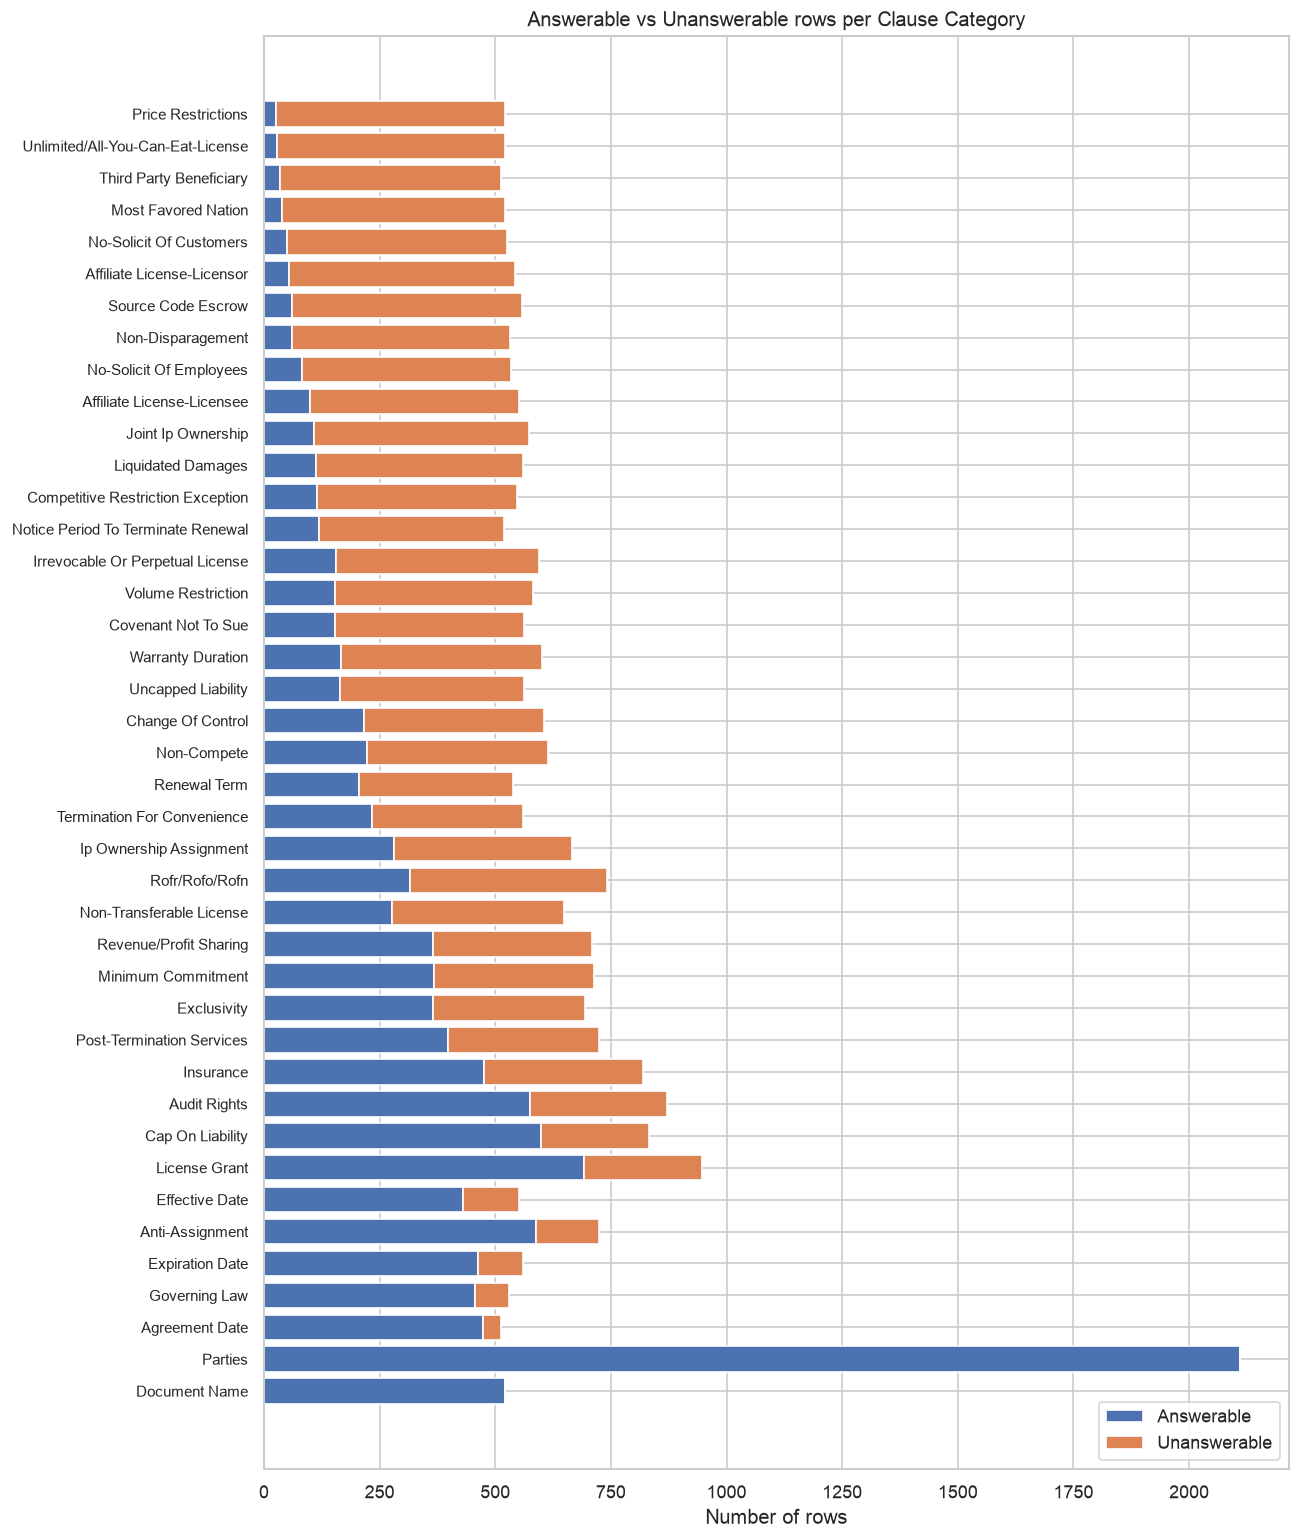

In [5]:
fig, ax = plt.subplots(figsize=(11, 13))

cats = cat_stats.index.tolist()
y = np.arange(len(cats))

ax.barh(y, cat_stats["answerable"],   label="Answerable",   color="#4C72B0")
ax.barh(y, cat_stats["unanswerable"], left=cat_stats["answerable"],
        label="Unanswerable", color="#DD8452")

ax.set_yticks(y)
ax.set_yticklabels(cats, fontsize=9)
ax.set_xlabel("Number of rows")
ax.set_title("Answerable vs Unanswerable rows per Clause Category")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 3. Answerable rate per category

The answerable rate tells us how often each clause type actually appears
across the 510 contracts. High-rate categories (e.g. Parties, Document Name)
appear in almost every contract; low-rate ones are rare and the model will
see far more negative examples for them.

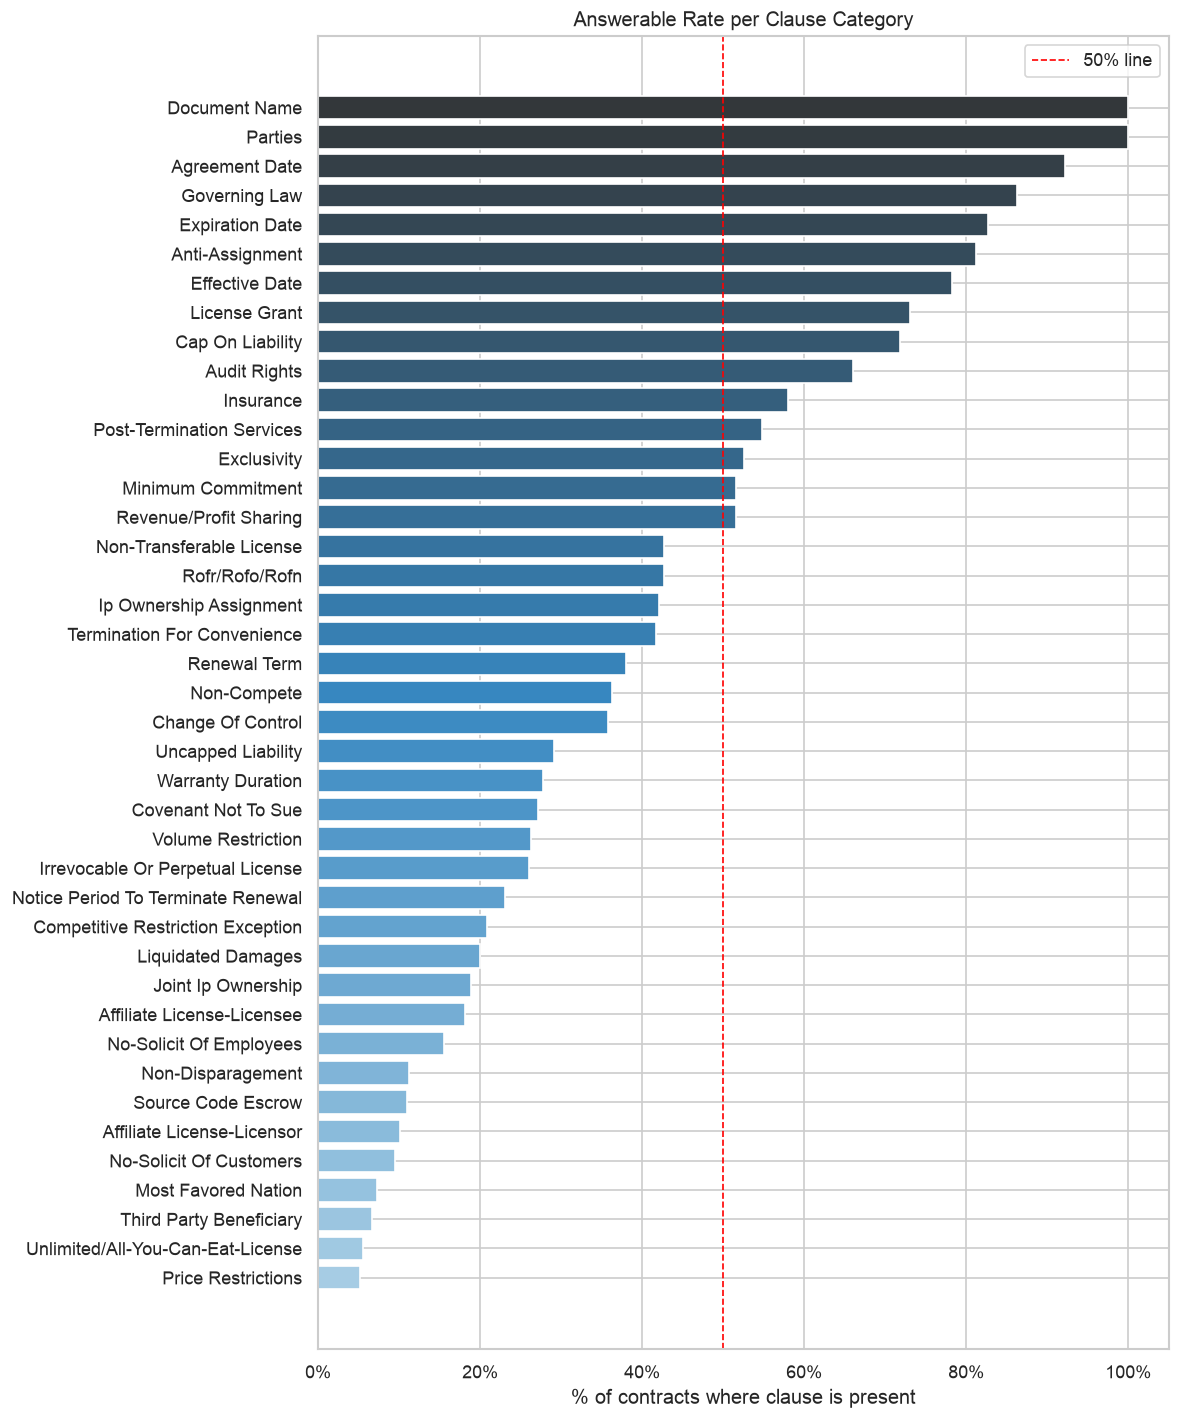

Most common clause:  Document Name (100.0%)
Rarest clause:       Price Restrictions (5.2%)


In [6]:
fig, ax = plt.subplots(figsize=(10, 12))

sorted_cats = cat_stats.sort_values("answerable_rate")
bars = ax.barh(
    sorted_cats.index,
    sorted_cats["answerable_rate"] * 100,
    color=sns.color_palette("Blues_d", len(sorted_cats)),
)
ax.axvline(50, color="red", linestyle="--", linewidth=1, label="50% line")
ax.set_xlabel("% of contracts where clause is present")
ax.set_title("Answerable Rate per Clause Category")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Most common clause:  {cat_stats['answerable_rate'].idxmax()} ({cat_stats['answerable_rate'].max()*100:.1f}%)")
print(f"Rarest clause:       {cat_stats['answerable_rate'].idxmin()} ({cat_stats['answerable_rate'].min()*100:.1f}%)")

## 4. Answer span length distribution

How long are the extracted clause spans? This affects the output layer
design and whether we need to handle multi-sentence spans.

Answer span length (chars):
count    12413.000000
mean       263.252799
std        285.731687
min          2.000000
25%         38.000000
50%        197.000000
75%        367.000000
max       3884.000000



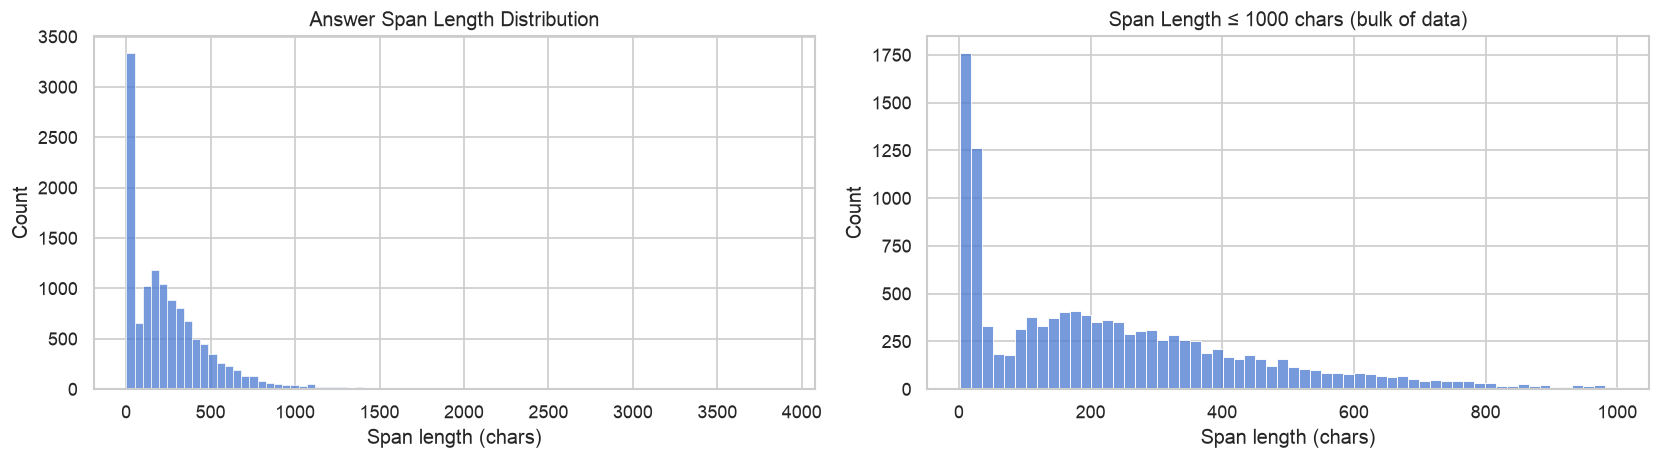

In [7]:
answerable = df[df["is_answerable"]].copy()
answerable["span_len"] = answerable["answer_text"].str.len()

print("Answer span length (chars):")
print(answerable["span_len"].describe().to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
sns.histplot(answerable["span_len"], bins=80, ax=axes[0])
axes[0].set_xlabel("Span length (chars)")
axes[0].set_ylabel("Count")
axes[0].set_title("Answer Span Length Distribution")

# Zoomed to ≤ 1000 chars to show the bulk
sns.histplot(answerable[answerable["span_len"] <= 1000]["span_len"],
             bins=60, ax=axes[1])
axes[1].set_xlabel("Span length (chars)")
axes[1].set_title("Span Length ≤ 1000 chars (bulk of data)")

plt.tight_layout()
plt.show()

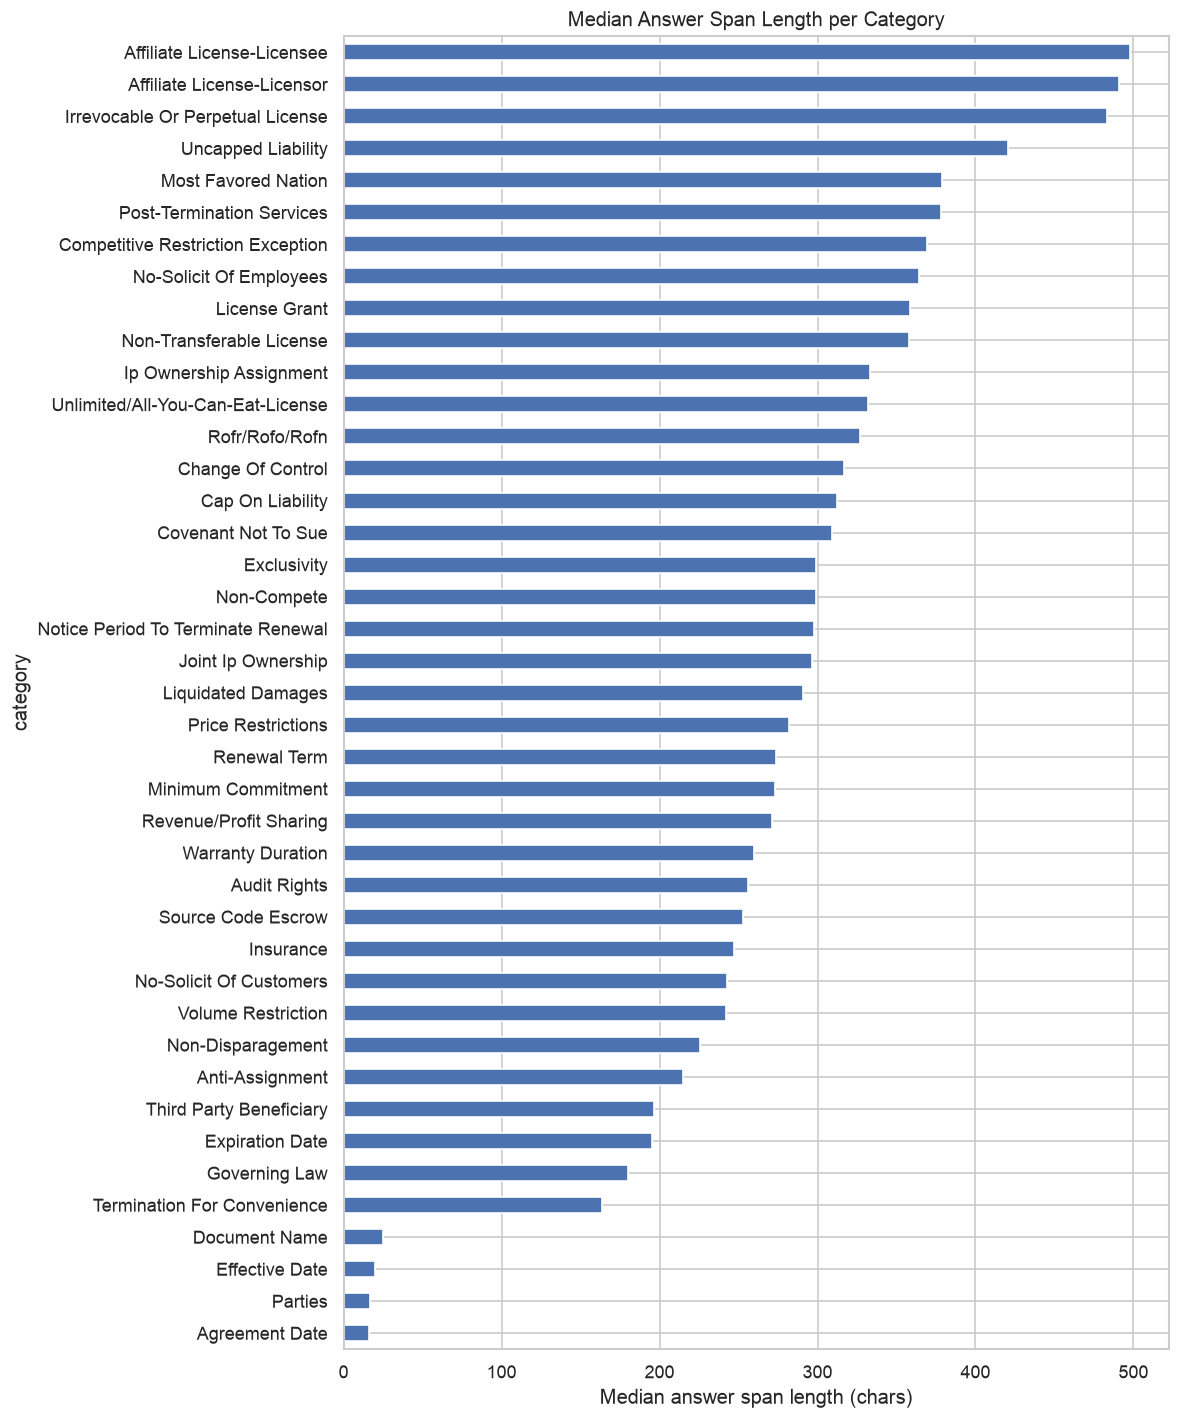

In [8]:
# Median span length per category — helps understand which clauses
# tend to be single phrases vs multi-sentence blocks.
span_by_cat = (
    answerable.groupby("category")["span_len"]
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 12))
span_by_cat.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Median answer span length (chars)")
ax.set_title("Median Answer Span Length per Category")
plt.tight_layout()
plt.show()

## 5. Contract length in tokens

LegalBERT's maximum input is 512 tokens. Since context repeats per
category row, we look at unique contracts only. The red line marks the
512-token hard limit — nearly every contract requires chunking.

Unique contracts: 510
count      510.000000
mean     10663.117647
std      11745.233572
min        168.000000
25%       3269.250000
50%       6643.500000
75%      13475.750000
max      78960.000000

Contracts within 512 tokens:     17
Contracts exceeding 512 tokens:  493 (96.7%)


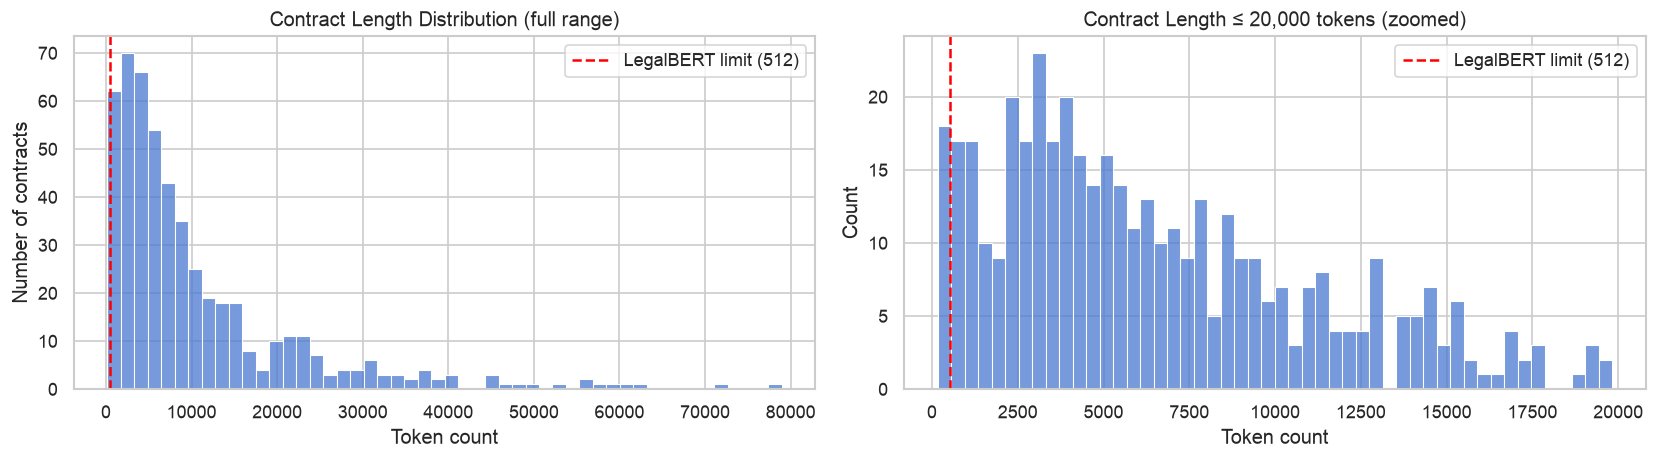

In [9]:
contract_lengths = (
    df.drop_duplicates(subset="contract_id")[["contract_id", "context_length_tokens"]]
)

max_len = 512
print(f"Unique contracts: {len(contract_lengths)}")
print(contract_lengths["context_length_tokens"].describe().to_string())
print(f"\nContracts within 512 tokens:     {(contract_lengths['context_length_tokens'] <= max_len).sum()}")
print(f"Contracts exceeding 512 tokens:  {(contract_lengths['context_length_tokens'] > max_len).sum()} ({(contract_lengths['context_length_tokens'] > max_len).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(contract_lengths["context_length_tokens"], bins=50, ax=axes[0])
axes[0].axvline(max_len, color="red", linestyle="--",
               label=f"LegalBERT limit ({max_len})")
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("Number of contracts")
axes[0].set_title("Contract Length Distribution (full range)")
axes[0].legend()

# Zoomed: contracts under 20 000 tokens
zoomed = contract_lengths[contract_lengths["context_length_tokens"] <= 20000]
sns.histplot(zoomed["context_length_tokens"], bins=50, ax=axes[1])
axes[1].axvline(max_len, color="red", linestyle="--",
               label=f"LegalBERT limit ({max_len})")
axes[1].set_xlabel("Token count")
axes[1].set_title("Contract Length ≤ 20,000 tokens (zoomed)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Train / test split validation

Checking the split is contract-level (no contract leaks across splits)
and that the category distribution is consistent between train and test.

In [10]:
train_contracts = set(df[df["split"]=="train"]["contract_id"])
test_contracts  = set(df[df["split"]=="test"]["contract_id"])
overlap = train_contracts & test_contracts
print(f"Contracts in train:         {len(train_contracts)}")
print(f"Contracts in test:          {len(test_contracts)}")
print(f"Contracts in both splits:   {len(overlap)}  ← must be 0")
print(f"Total unique contracts:     {len(train_contracts | test_contracts)}")

Contracts in train:         408
Contracts in test:          102
Contracts in both splits:   0  ← must be 0
Total unique contracts:     510


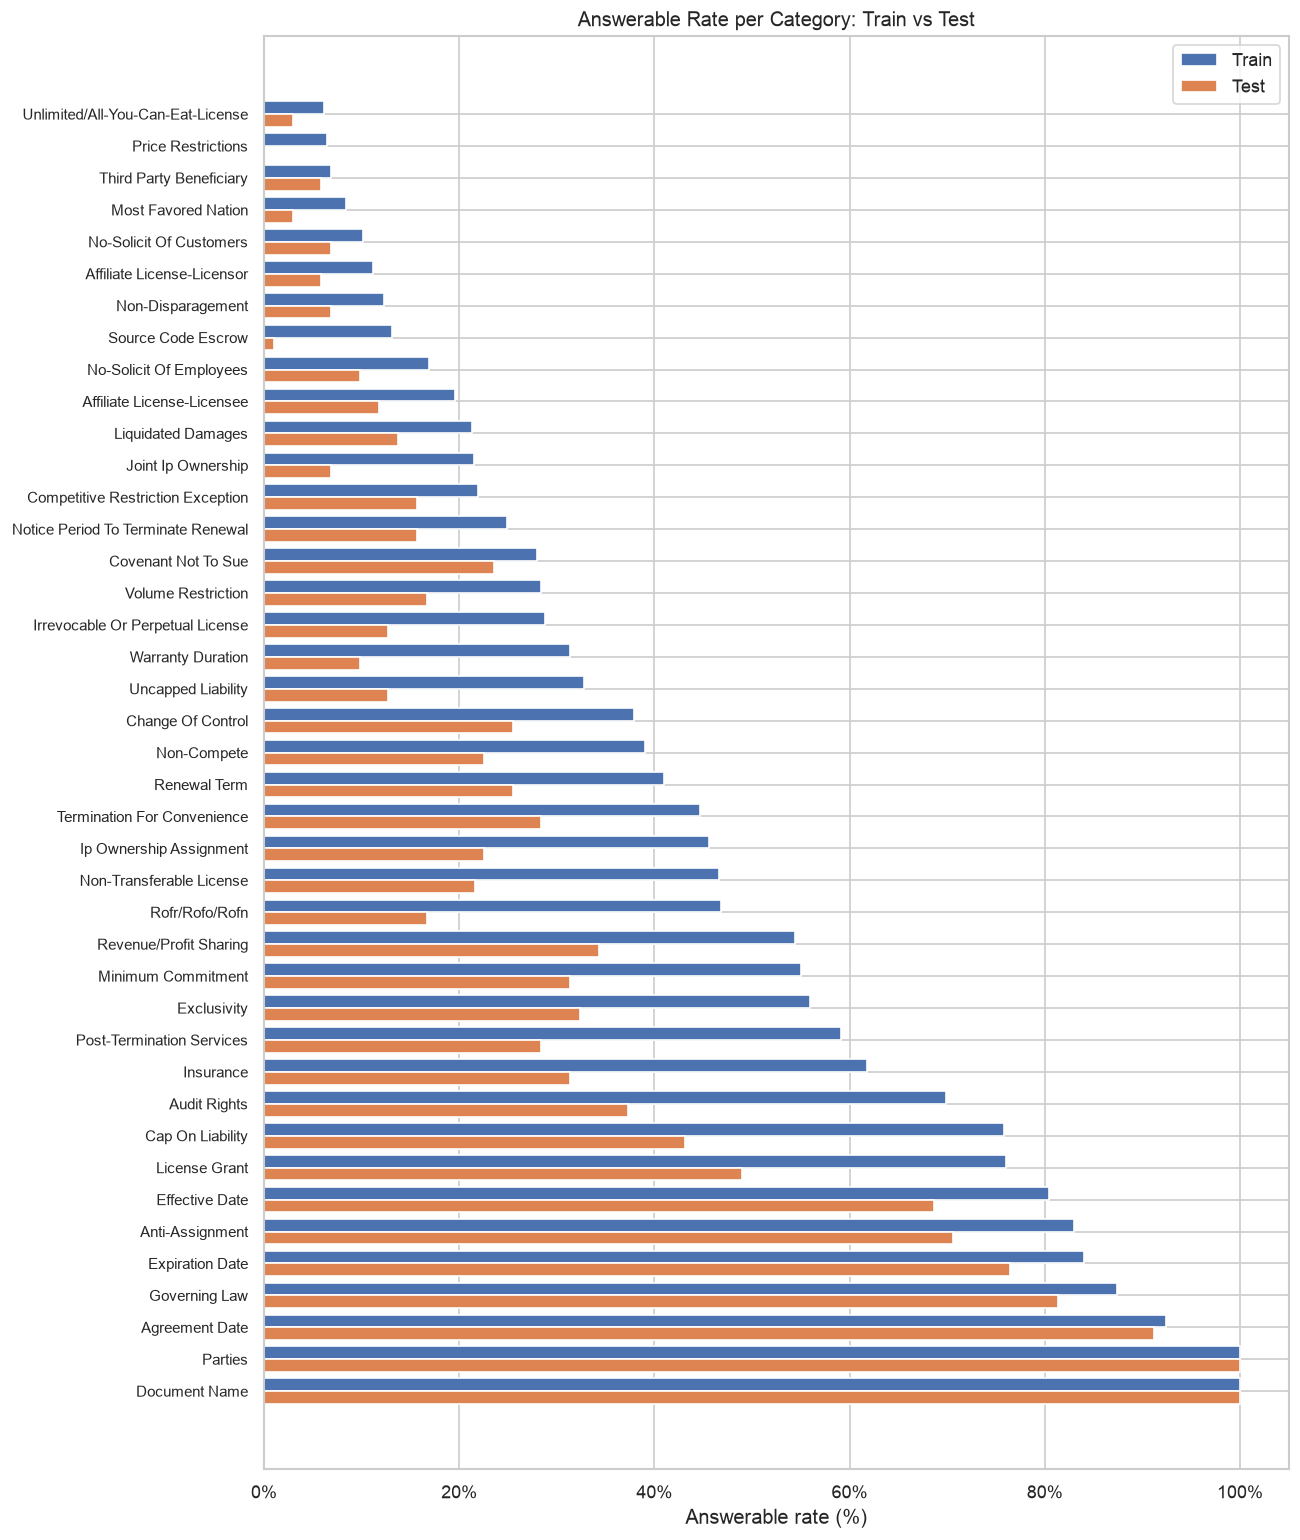


Largest train/test answerable-rate gaps:
split                         train      test      diff
category                                               
Cap On Liability           0.757866  0.431373  0.326493
Audit Rights               0.698701  0.372549  0.326152
Post-Termination Services  0.590690  0.284314  0.306376
Insurance                  0.617852  0.313725  0.304127
Rofr/Rofo/Rofn             0.467919  0.166667  0.301252
License Grant              0.759763  0.490196  0.269567
Non-Transferable License   0.466179  0.215686  0.250493
Exclusivity                0.559865  0.323529  0.236336
Minimum Commitment         0.549918  0.313725  0.236193
Ip Ownership Assignment    0.455674  0.225490  0.230184


In [11]:
# Answerable rate per category in train vs test side by side
split_rate = (
    df.groupby(["split", "category"])["is_answerable"]
    .mean()
    .unstack(level=0)
    .sort_values("train", ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 13))
x = np.arange(len(split_rate))
w = 0.4
ax.barh(x + w/2, split_rate["train"] * 100, w, label="Train", color="#4C72B0")
ax.barh(x - w/2, split_rate["test"]  * 100, w, label="Test",  color="#DD8452")
ax.set_yticks(x)
ax.set_yticklabels(split_rate.index, fontsize=9)
ax.set_xlabel("Answerable rate (%)")
ax.set_title("Answerable Rate per Category: Train vs Test")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
ax.legend()
plt.tight_layout()
plt.show()

# Biggest train/test rate differences
split_rate["diff"] = (split_rate["train"] - split_rate["test"]).abs()
print("\nLargest train/test answerable-rate gaps:")
print(split_rate.sort_values("diff", ascending=False)[["train","test","diff"]].head(10).to_string())